In [1]:
# =============================================================================
# PARAMETERS - Edit these
# =============================================================================
N_POINTS = 50000      # Number of points for both present and past
TIME_MA = 150         # Past time in millions of years (e.g., 90, 150, 200)
SEED = 42            # Random seed for reproducibility
MODEL = "ZAHIROVIC2022"  # GPlates reconstruction model
import sys
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['HIP_VISIBLE_DEVICES'] = '7'  # or '0', '4', '5', '6', '7' - any idle GPU

# alternatives: "MULLER2019", "ZAHIROVIC2022" MULLER2022

In [2]:
import numpy as np
import requests
from shapely.geometry import Point, shape
from shapely.prepared import prep
from shapely.ops import unary_union

GWS_COASTLINES = "https://gws.gplates.org/reconstruct/coastlines/"
GWS_PLATES = "https://gws.gplates.org/topology/plate_polygons"


def fetch_geojson(time_ma: float, model: str = "MULLER2019") -> dict:
    """Fetch coastline polygons from GPlates Web Service."""
    params = {"time": float(time_ma), "model": model, "wrap": "true"}
    r = requests.get(GWS_COASTLINES, params=params, timeout=60)
    r.raise_for_status()
    return r.json()


def fetch_plate_polygons(time_ma: float, model: str = "ZAHIROVIC2022") -> dict:
    """Fetch tectonic plate polygons from GPlates Web Service."""
    params = {"time": float(time_ma), "model": model}
    r = requests.get(GWS_PLATES, params=params, timeout=60)
    r.raise_for_status()
    return r.json()


def make_valid_geom(g):
    """Clean invalid geometries."""
    if g is None or g.is_empty:
        return None
    try:
        import shapely
        g2 = shapely.make_valid(g) if hasattr(shapely, "make_valid") else g.buffer(0)
    except Exception:
        g2 = g.buffer(0)
    return g2 if (g2 is not None and not g2.is_empty) else None


def geojson_to_prepared_union(geojson: dict):
    """Parse GeoJSON and return prepared union polygon for fast containment tests."""
    polys = []
    for f in geojson.get("features", []):
        geom = f.get("geometry")
        if not geom:
            continue
        g = make_valid_geom(shape(geom))
        if g and g.geom_type in ("Polygon", "MultiPolygon"):
            polys.append(g)
    if not polys:
        raise ValueError("No polygonal geometries found")
    U = make_valid_geom(unary_union(polys))
    return prep(U)


def build_plate_lookup(geojson: dict):
    """Build list of (plate_id, plate_name, prepared_geometry) for containment tests."""
    plates = []
    for f in geojson.get("features", []):
        props = f.get("properties", {})
        plate_id = props.get("pid")  # GWS uses 'pid' for plate ID
        plate_name = props.get("name", "")
        geom = f.get("geometry")
        if not geom or plate_id is None:
            continue
        g = make_valid_geom(shape(geom))
        if g and g.geom_type in ("Polygon", "MultiPolygon"):
            plates.append((plate_id, plate_name, prep(g)))
    return plates


def assign_plates(lat, lon, plates):
    """Assign plate IDs to lat/lon points. Returns array of plate IDs."""
    plate_ids = np.full(len(lat), -1, dtype=int)
    for i, (la, lo) in enumerate(zip(lat, lon)):
        pt = Point(lo, la)
        for pid, pname, prepped in plates:
            if prepped.contains(pt):
                plate_ids[i] = pid
                break
    return plate_ids


def latlon_to_xyz(lat_deg, lon_deg):
    """Convert lat/lon (degrees) to unit vectors on S²."""
    lat, lon = np.deg2rad(lat_deg), np.deg2rad(lon_deg)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)
    X = np.stack([x, y, z], axis=-1)
    return X / np.linalg.norm(X, axis=1, keepdims=True)


def xyz_to_latlon_deg(xyz):
    """Convert unit vectors to lat/lon (degrees)."""
    xyz = np.asarray(xyz)
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    lat = np.rad2deg(np.arcsin(np.clip(z, -1, 1)))
    lon = np.rad2deg(np.arctan2(y, x))
    return lat, lon


def sample_points_on_land(prepped_union, n: int, seed: int = 0, batch: int = 200_000):
    """Rejection sample n points uniformly on S² restricted to land."""
    rng = np.random.default_rng(seed)
    out_lat, out_lon = [], []
    
    while len(out_lat) < n:
        lon = rng.uniform(-180, 180, batch)
        lat = np.rad2deg(np.arcsin(rng.uniform(-1, 1, batch)))
        keep = [prepped_union.contains(Point(lo, la)) for la, lo in zip(lat, lon)]
        out_lat.extend(lat[keep])
        out_lon.extend(lon[keep])
    
    return np.array(out_lat[:n]), np.array(out_lon[:n])

In [3]:
# Fetch coastlines and sample points
print(f"Fetching coastlines for 0 Ma and {TIME_MA} Ma...")
U_present = geojson_to_prepared_union(fetch_geojson(0, MODEL))
U_past = geojson_to_prepared_union(fetch_geojson(TIME_MA, MODEL))

print(f"Sampling {N_POINTS} points on present-day land...")
lat_present, lon_present = sample_points_on_land(U_present, N_POINTS, seed=SEED)

print(f"Sampling {N_POINTS} points on {TIME_MA} Ma land...")
lat_past, lon_past = sample_points_on_land(U_past, N_POINTS, seed=SEED + 1)

# Convert to unit vectors on S²
X_present = latlon_to_xyz(lat_present, lon_present)
X_past = latlon_to_xyz(lat_past, lon_past)

print(f"\nX_present: {X_present.shape}, X_past: {X_past.shape}")

# Fetch plate polygons and assign plate IDs
print(f"\nFetching plate polygons for 0 Ma and {TIME_MA} Ma...")
plates_present = build_plate_lookup(fetch_plate_polygons(0, MODEL))
plates_past = build_plate_lookup(fetch_plate_polygons(TIME_MA, MODEL))

print(f"Assigning plate IDs to {N_POINTS} present-day points...")
plate_ids_present = assign_plates(lat_present, lon_present, plates_present)

print(f"Assigning plate IDs to {N_POINTS} past points...")
plate_ids_past = assign_plates(lat_past, lon_past, plates_past)

print(f"\nUnique plates (present): {len(np.unique(plate_ids_present))}")
print(f"Unique plates (past): {len(np.unique(plate_ids_past))}")

Fetching coastlines for 0 Ma and 150 Ma...
Sampling 50000 points on present-day land...
Sampling 50000 points on 150 Ma land...

X_present: (50000, 3), X_past: (50000, 3)

Fetching plate polygons for 0 Ma and 150 Ma...
Assigning plate IDs to 50000 present-day points...
Assigning plate IDs to 50000 past points...

Unique plates (present): 29
Unique plates (past): 23


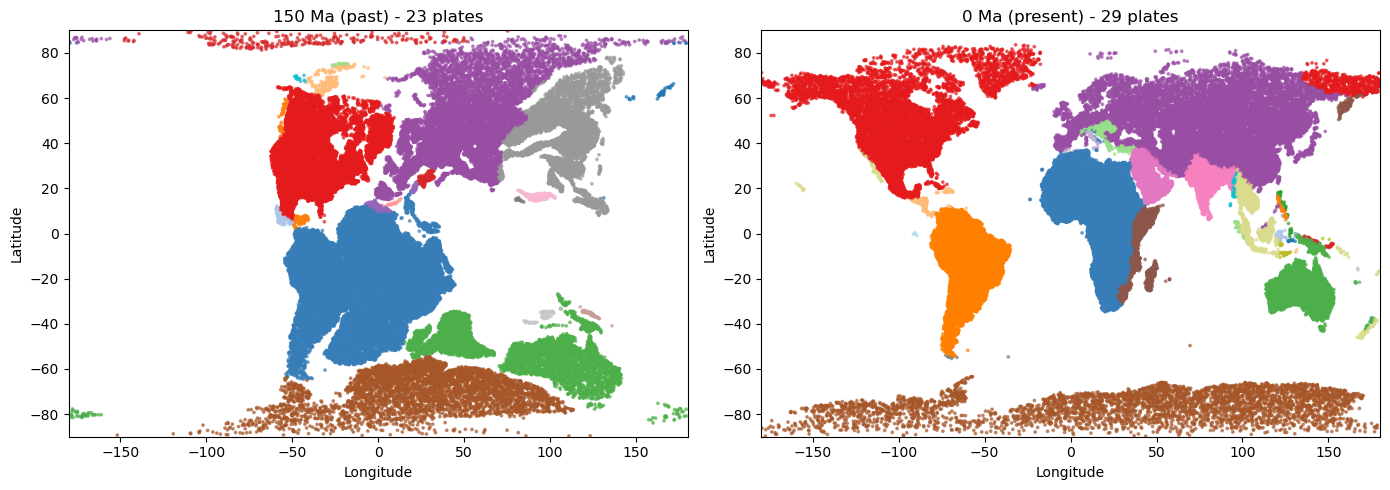


Major plate color assignments:
  Plate 101 (NAM_4-0Ma                     ): #e41a1c - Present:  8629, Past:  7691
  Plate 201 (SAM                           ): #ff7f00 - Present:  5975, Past:     0
  Plate 301 (Eurasia_1_0                   ): #984ea3 - Present: 12888, Past:  9050
  Plate 380 (Mongol-Okhotsk Ocean          ): #999999 - Present:     0, Past:  4674
  Plate 501 (India from PB03 GS            ): #f781bf - Present:  1397, Past:     0
  Plate 701 (Africa                        ): #377eb8 - Present:  9104, Past: 17866
  Plate 801 (Australia                     ): #4daf4a - Present:  2894, Past:  4762
  Plate 802 (Antarctica                    ): #a65628 - Present:  4114, Past:  4380


In [4]:
# Plot both distributions colored by tectonic plate
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Manual color assignment for major plates to ensure they're visually distinct
major_plate_colors = {
    101: '#e41a1c',  # North America - red
    201: '#ff7f00',  # South America - orange  
    301: '#984ea3',  # Eurasia - purple
    701: '#377eb8',  # Africa - blue
    801: '#4daf4a',  # Australia - green
    802: '#a65628',  # Antarctica - brown
    501: '#f781bf',  # India - pink
    380: '#999999',  # Mongol-Okhotsk - gray
    # Add more if needed
}

# Get all unique plate IDs
all_plate_ids = np.unique(np.concatenate([plate_ids_past, plate_ids_present]))

# Create color list for all plates
colors = []
for pid in all_plate_ids:
    if pid in major_plate_colors:
        colors.append(major_plate_colors[pid])
    else:
        # Use a distinct color from tab20 for minor plates
        idx = len(colors) % 20
        colors.append(plt.cm.tab20(idx))

# Create custom colormap
cmap = mcolors.ListedColormap(colors)
id_to_idx = {pid: i for i, pid in enumerate(all_plate_ids)}

plate_colors_past = np.array([id_to_idx[pid] for pid in plate_ids_past])
plate_colors_present = np.array([id_to_idx[pid] for pid in plate_ids_present])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(lon_past, lat_past, c=plate_colors_past, cmap=cmap, 
                       vmin=0, vmax=len(all_plate_ids)-1, s=3, alpha=0.6)
axes[0].set_title(f"{TIME_MA} Ma (past) - {len(np.unique(plate_ids_past))} plates")
axes[0].set_xlim(-180, 180); axes[0].set_ylim(-90, 90)
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

sc1 = axes[1].scatter(lon_present, lat_present, c=plate_colors_present, cmap=cmap,
                       vmin=0, vmax=len(all_plate_ids)-1, s=3, alpha=0.6)
axes[1].set_title(f"0 Ma (present) - {len(np.unique(plate_ids_present))} plates")
axes[1].set_xlim(-180, 180); axes[1].set_ylim(-90, 90)
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

# Print major plates and their colors
print(f"\nMajor plate color assignments:")
for pid in sorted(major_plate_colors.keys()):
    pname_present = [n for p, n, _ in plates_present if p == pid]
    pname_past = [n for p, n, _ in plates_past if p == pid]
    pname = pname_present[0] if pname_present else (pname_past[0] if pname_past else "Unknown")
    count_present = (plate_ids_present == pid).sum()
    count_past = (plate_ids_past == pid).sum()
    print(f"  Plate {pid:3d} ({pname:30s}): {major_plate_colors[pid]} - Present: {count_present:5d}, Past: {count_past:5d}")

In [5]:
# Save to CSV with plate IDs
import pandas as pd

def write_latlon_csv_with_plates(X, plate_ids, filename):
    """Write (N,3) unit vectors to CSV with lat, lon, and plate_id columns."""
    lat, lon = xyz_to_latlon_deg(X)
    df = pd.DataFrame({"lat": lat, "lon": lon, "plate_id": plate_ids})
    df.to_csv(filename, index=False)

write_latlon_csv_with_plates(X_present, plate_ids_present, "data/land_points_present.csv")
write_latlon_csv_with_plates(X_past, plate_ids_past, "data/land_points_past.csv")

print(f"Saved {N_POINTS} points each with plate IDs:")
print(f"  Present (0 Ma):      data/land_points_present.csv")
print(f"  Past ({TIME_MA} Ma): data/land_points_past.csv")

# Summary statistics
print(f"\nPlate distribution (present):")
unique_present, counts_present = np.unique(plate_ids_present, return_counts=True)
for pid, count in sorted(zip(unique_present, counts_present), key=lambda x: -x[1])[:5]:
    pname = [n for p, n, _ in plates_present if p == pid]
    pname_str = pname[0] if pname else "Unknown"
    print(f"  Plate {pid:3d} ({pname_str:30s}): {count:5d} points ({100*count/N_POINTS:.1f}%)")

print(f"\nPlate distribution (past):")
unique_past, counts_past = np.unique(plate_ids_past, return_counts=True)
for pid, count in sorted(zip(unique_past, counts_past), key=lambda x: -x[1])[:5]:
    pname = [n for p, n, _ in plates_past if p == pid]
    pname_str = pname[0] if pname else "Unknown"
    print(f"  Plate {pid:3d} ({pname_str:30s}): {count:5d} points ({100*count/N_POINTS:.1f}%)")

Saved 50000 points each with plate IDs:
  Present (0 Ma):      data/land_points_present.csv
  Past (150 Ma): data/land_points_past.csv

Plate distribution (present):
  Plate 301 (Eurasia_1_0                   ): 12888 points (25.8%)
  Plate 701 (Africa                        ):  9104 points (18.2%)
  Plate 101 (NAM_4-0Ma                     ):  8629 points (17.3%)
  Plate 201 (SAM                           ):  5975 points (11.9%)
  Plate 802 (Antarctica                    ):  4114 points (8.2%)

Plate distribution (past):
  Plate 701 (West Gondwana                 ): 17866 points (35.7%)
  Plate 301 (Eurasia                       ):  9050 points (18.1%)
  Plate 101 (NAM                           ):  7691 points (15.4%)
  Plate 801 (East Gondwana                 ):  4762 points (9.5%)
  Plate 380 (Mongol-Okhotsk Ocean          ):  4674 points (9.3%)
